# 01 · Vectors as Arrows
<sub>Math Foundations Sandbox &nbsp;·&nbsp; a hands-on geometry-for-robotics manual </sub>

---

### Where this sits in the manual
This is the very first brick. Everything later — rotations, coordinate frames,
the pose of a drone, a camera tracking that drone — is built out of **vectors**.
Before we can *transform* geometry we must be fluent in *representing* it.

### Learning objectives
By the end of this notebook you will be able to:
1. Represent a vector as a NumPy array and draw it as an arrow.
2. Add and subtract vectors and scale them, both algebraically and geometrically.
3. Compute a vector's **length** (norm) and turn it into a **unit vector**.
4. Read a vector two ways at once: as *displacement* (an arrow) and as a *point*.
5. Animate a point moving along a path — your first taste of motion.

### How to use this notebook
Run every cell in order (Shift+Enter). Comments explain *why* each line exists,
not merely what it does. The **Try it yourself** boxes have worked solutions in
the cell immediately below them — attempt them first, then check.


In [1]:
# === Standard setup used throughout this notebook ========================
import numpy as np                 # NumPy = fast vector/matrix math, so we never hand-write loops for arithmetic.
import matplotlib.pyplot as plt     # Matplotlib is our plotting engine for every static figure below.
from matplotlib import animation   # Turns a list of frames into a playable movie (used for the animations).
from IPython.display import HTML    # Embeds an animation as a self-contained JS player (no ffmpeg required).

%matplotlib inline
# Render animations as an in-browser JavaScript player so they always play, on any machine.
plt.rcParams["animation.html"] = "jshtml"
# Raise the embed size cap (MB) so longer clips are not silently cut off.
plt.rcParams["animation.embed_limit"] = 60
# One consistent, readable look for every figure in the manual.
plt.rcParams.update({"figure.dpi": 80, "font.size": 11, "axes.grid": True})
# Print matrices with 3 decimals and no scientific notation, so output is easy to eyeball.
np.set_printoptions(precision=3, suppress=True)
print("Setup complete — NumPy", np.__version__, "| Matplotlib", plt.matplotlib.__version__)

Setup complete — NumPy 2.4.4 | Matplotlib 3.10.8


In [2]:
def draw_vector(ax, tip, tail=(0.0, 0.0), color="C0", label=None, lw=2.2):
    """Draw a 2-D vector as an arrow from `tail` to `tip`.

    Why an annotation and not ax.plot? `annotate` with arrowprops gives us a
    real arrowhead whose size stays fixed in screen space, so the arrow looks
    right no matter how the axes are zoomed.
    """
    tail = np.asarray(tail, float)                 # Accept plain tuples/lists but work in float arrays internally.
    tip  = np.asarray(tip,  float)
    ax.annotate("", xy=tip, xytext=tail,           # Empty text: we only want the arrow, not a caption here.
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                shrinkA=0, shrinkB=0))  # shrink=0 so the arrow touches the exact endpoints.
    if label:                                      # Optionally print the vector's name near its midpoint.
        mid = tail + 0.5 * (tip - tail)            # Midpoint of the arrow, a natural spot for the label.
        ax.text(mid[0], mid[1], "  " + label, color=color,
                fontsize=12, ha="left", va="bottom")

def square_axes(ax, lim):
    """Force equal aspect + symmetric limits.

    Why: rotations and angles only *look* correct when one unit on x equals one
    unit on y. Without equal aspect a circle would render as an ellipse and a
    90-degree turn would look like something else.
    """
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim) # Symmetric window centred on the origin.
    ax.set_aspect("equal", adjustable="box")       # 1 unit in x == 1 unit in y on screen.
    ax.axhline(0, color="0.7", lw=1); ax.axvline(0, color="0.7", lw=1)  # Faint axes through the origin.

## 1 · A vector is an ordered list of numbers

A 2-D vector is just two numbers, $\mathbf{v} = \begin{bmatrix} v_x \\ v_y \end{bmatrix}$.
We store it as a NumPy array because that lets us add, scale, and later multiply
by matrices using fast built-in operations instead of writing loops by hand.

Geometrically we picture $\mathbf{v}$ as an **arrow**: it has a *length* and a
*direction*. Crucially, an arrow does **not** care where it starts — only its
length and direction matter. We usually draw it starting from the origin, but
the same vector $\begin{bmatrix}3\\2\end{bmatrix}$ means "go 3 right and 2 up"
from *wherever* you are.


v      = [3. 2.]
v_x    = 3.0
v_y    = 2.0
shape  = (2,)


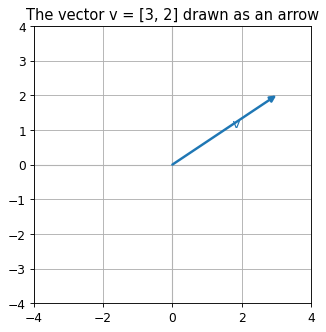

In [3]:
# A 2-D vector is stored as a 1-D array of two floats. We use floats (3.0 not 3)
# so that later divisions (e.g. normalising) don't get silently truncated.
v = np.array([3.0, 2.0])
print("v      =", v)          # The raw components.
print("v_x    =", v[0])       # Index 0 is the x-component (how far right).
print("v_y    =", v[1])       # Index 1 is the y-component (how far up).
print("shape  =", v.shape)    # (2,) confirms it's a single 2-D vector, not a matrix.

fig, ax = plt.subplots(figsize=(4.5, 4.5))   # A single square canvas so the geometry isn't distorted.
draw_vector(ax, v, label="v")                # Draw v as an arrow from the origin.
square_axes(ax, 4)                           # Equal aspect + symmetric limits (see helper for why).
ax.set_title("The vector v = [3, 2] drawn as an arrow")
plt.show()


## 2 · Adding vectors: tip-to-tail

Vector addition $\mathbf{a}+\mathbf{b}$ has a clean picture: place the tail of
$\mathbf{b}$ at the **tip** of $\mathbf{a}$; the sum is the arrow from the very
start to the very end. Algebraically you just add components. Both views must
agree — the plot below shows they do.

This "tip-to-tail" idea is exactly how a robot composes displacements: *move
along $\mathbf{a}$, then along $\mathbf{b}$* lands you at $\mathbf{a}+\mathbf{b}$.


a + b = [4.  3.5]


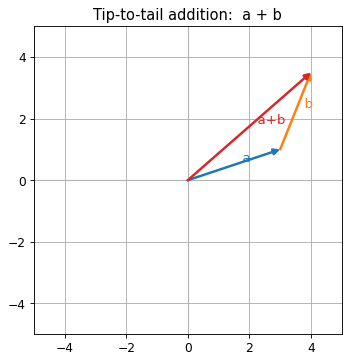

In [4]:
a = np.array([3.0, 1.0])     # First displacement: 3 right, 1 up.
b = np.array([1.0, 2.5])     # Second displacement: 1 right, 2.5 up.
s = a + b                    # Component-wise sum — NumPy adds element by element for us.
print("a + b =", s)          # Should read [4.0, 3.5].

fig, ax = plt.subplots(figsize=(5, 5))
draw_vector(ax, a, color="C0", label="a")              # a from the origin.
draw_vector(ax, a + b, tail=a, color="C1", label="b")  # b starts at the TIP of a (tip-to-tail).
draw_vector(ax, s, color="C3", label="a+b")            # The resultant, straight from origin to end.
square_axes(ax, 5)
ax.set_title("Tip-to-tail addition:  a + b")
plt.show()


## 3 · Scaling a vector

Multiplying by a scalar $k$ stretches ($|k|>1$), shrinks ($|k|<1$), or flips
($k<0$) the arrow **without changing the line it lies on**. This is the seed of
everything that follows: a *velocity* is a direction scaled by a speed; a
*force* is a direction scaled by a magnitude.


k = +2.0  ->  [4. 2.]
k = +1.0  ->  [2. 1.]
k = -1.5  ->  [-3.  -1.5]


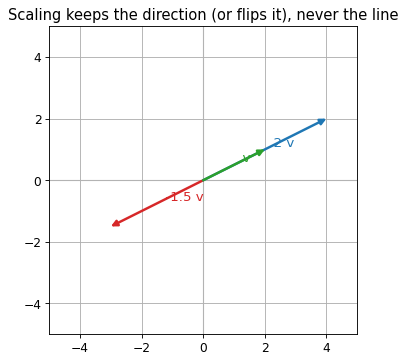

In [5]:
v = np.array([2.0, 1.0])      # A base direction.
for k, col in [(2.0, "C0"), (1.0, "C2"), (-1.5, "C3")]:  # Three scalars: stretch, original, flip+stretch.
    scaled = k * v            # Scalar * array multiplies every component — no loop needed.
    print(f"k = {k:+.1f}  ->  {scaled}")

fig, ax = plt.subplots(figsize=(5, 5))
draw_vector(ax, -1.5 * v, color="C3", label="-1.5 v")   # Flipped and longer (points the opposite way).
draw_vector(ax,  2.0 * v, color="C0", label="2 v")      # Twice as long, same direction.
draw_vector(ax,  1.0 * v, color="C2", label="v")        # The original, drawn last so it sits on top.
square_axes(ax, 5)
ax.set_title("Scaling keeps the direction (or flips it), never the line")
plt.show()


## 4 · Length (norm) and unit vectors

The **length** (Euclidean norm) of $\mathbf{v}$ is
$\lVert\mathbf{v}\rVert = \sqrt{v_x^2 + v_y^2}$ — Pythagoras. A **unit vector**
$\hat{\mathbf{v}} = \mathbf{v}/\lVert\mathbf{v}\rVert$ has length exactly 1 and
keeps only the *direction*. Robots lean on this constantly: "which way should I
go?" is a unit vector; "how fast?" is a separate scalar.


length        = 5.0
unit vector   = [0.6 0.8]
its length    = 1.0  (should be 1.0)


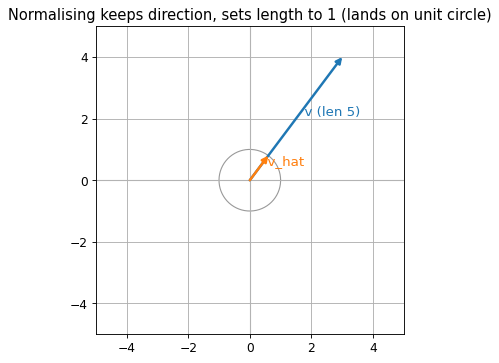

In [6]:
v = np.array([3.0, 4.0])                 # Chosen as a 3-4-5 triangle so the length is a clean 5.
length = np.linalg.norm(v)               # np.linalg.norm computes sqrt(vx^2+vy^2) for us (and generalises to any dimension).
v_hat  = v / length                      # Dividing by the length rescales to length 1 — this is normalisation.
print("length        =", length)        # Expect 5.0.
print("unit vector   =", v_hat)          # Expect [0.6, 0.8].
print("its length    =", np.linalg.norm(v_hat), " (should be 1.0)")  # Sanity check that normalisation worked.

fig, ax = plt.subplots(figsize=(5, 5))
draw_vector(ax, v, color="C0", label="v (len 5)")     # The full-length vector.
draw_vector(ax, v_hat, color="C1", label="v_hat")     # Same direction, length 1.
theta = np.linspace(0, 2*np.pi, 200)                  # A dense parameter sweep to draw a smooth circle...
ax.plot(np.cos(theta), np.sin(theta), "0.6", lw=1)    # ...the unit circle, so we can SEE that v_hat lands on it.
square_axes(ax, 5)
ax.set_title("Normalising keeps direction, sets length to 1 (lands on unit circle)")
plt.show()


## 5 · Two readings of the same array: point vs displacement

The pair $[3, 2]$ can mean a **point** (a location) or a **displacement** (an
arrow / how to move). Same numbers, two jobs. Keeping this dual reading straight
is what makes coordinate frames (Notebook 06) click later on.


P     = [3. 2.]
Q     = [1. 3.]
Q - P = [-2.  1.]  (the displacement from P to Q)


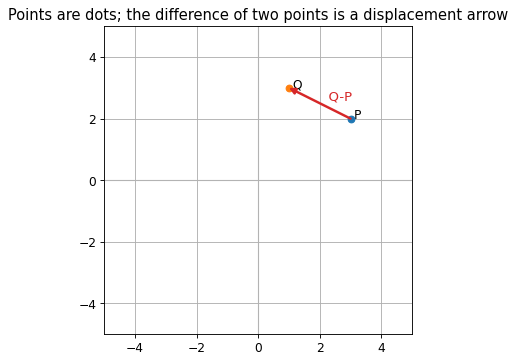

In [7]:
P = np.array([3.0, 2.0])   # Read as a POINT: the location (3, 2).
Q = np.array([1.0, 3.0])   # Another point.
d = Q - P                  # Read as a DISPLACEMENT: the arrow that takes you FROM P TO Q.
print("P     =", P)
print("Q     =", Q)
print("Q - P =", d, " (the displacement from P to Q)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*P, "o", color="C0"); ax.text(P[0]+0.1, P[1], "P")   # Draw P as a dot (a location, not an arrow).
ax.plot(*Q, "o", color="C1"); ax.text(Q[0]+0.1, Q[1], "Q")
draw_vector(ax, Q, tail=P, color="C3", label="Q-P")          # The displacement arrow from P to Q.
square_axes(ax, 5)
ax.set_title("Points are dots; the difference of two points is a displacement arrow")
plt.show()


## 🧪 Try it yourself

**E1.** Create `u = [4, 3]` and `w = [-1, 2]`. Compute `u + w`, `u - w`, and
`2*u - w`. Predict each result before running, then draw all three on one plot.

**E2.** Write a one-line function `unit(x)` that returns the unit vector of any
`x`, and verify its output has length 1 for `x = [5, -12]` (another Pythagorean
triple — what length do you expect *before* normalising?).


u + w     = [3. 5.]
u - w     = [5. 1.]
2u - w    = [9. 4.]


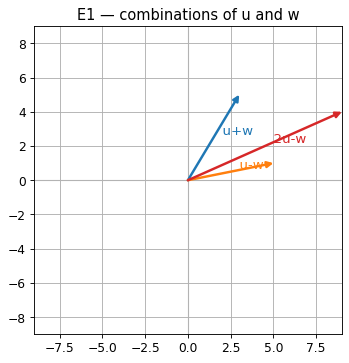

raw length = 13.0
unit(x)    = [ 0.385 -0.923]  length = 1.0


In [8]:
# --- Solution E1 -------------------------------------------------------------
u = np.array([4.0, 3.0])                  # First vector.
w = np.array([-1.0, 2.0])                 # Second vector (note the negative x, so it points left).
print("u + w     =", u + w)               # Component-wise sum.
print("u - w     =", u - w)               # Component-wise difference = u + (-w).
print("2u - w    =", 2*u - w)             # Scale u by 2, then subtract w.

fig, ax = plt.subplots(figsize=(5, 5))
draw_vector(ax, u + w,    color="C0", label="u+w")
draw_vector(ax, u - w,    color="C1", label="u-w")
draw_vector(ax, 2*u - w,  color="C3", label="2u-w")
square_axes(ax, 9)
ax.set_title("E1 — combinations of u and w")
plt.show()

# --- Solution E2 -------------------------------------------------------------
def unit(x):
    # Normalise: divide by length so the result points the same way but has length 1.
    return np.asarray(x, float) / np.linalg.norm(x)

x = np.array([5.0, -12.0])                # 5-12-13 triple, so the raw length is 13.
print("raw length =", np.linalg.norm(x)) # Expect 13.0.
print("unit(x)    =", unit(x), " length =", np.linalg.norm(unit(x)))  # Expect length 1.0.


## 🚁 Mini-exercise → motion: a point tracing a circle

Our first animation. A point moving on a circle is the simplest non-trivial
*trajectory*, and it is literally the top-down path of a drone doing a steady
banked turn. We build the frames once and let Matplotlib play them.


In [9]:
R = 2.0                                        # Radius of the circular path (metres, say).
n_frames = 60                                  # 60 frames -> a smooth loop that still renders quickly.
angles = np.linspace(0, 2*np.pi, n_frames)     # One full lap, split into equal angular steps.

fig, ax = plt.subplots(figsize=(4.8, 4.8))
square_axes(ax, R + 0.6)                        # Give the circle a little breathing room in the window.
ax.plot(R*np.cos(angles), R*np.sin(angles), "0.8", lw=1)  # Draw the full path once, as a faint guide.
(dot,)   = ax.plot([], [], "o", color="C3", ms=10)        # Empty marker we will move each frame (the "drone").
(trail,) = ax.plot([], [], "-", color="C0", lw=2)         # A growing trail so the motion is easy to read.
ax.set_title("A point tracing a circle (top-down drone turn)")

def update(i):
    # Called once per frame; i is the frame index. We recompute the point's
    # position and the trail up to this frame, then hand the updated artists back.
    x = R*np.cos(angles[:i+1]); y = R*np.sin(angles[:i+1])  # Path from start up to the current frame.
    dot.set_data([x[-1]], [y[-1]])                          # Move the marker to the newest point.
    trail.set_data(x, y)                                    # Extend the trail behind it.
    return dot, trail

# FuncAnimation repeatedly calls update(i) to build the movie. blit=False keeps
# things simple and robust (we are not micro-optimising redraws here).
anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=40, blit=False)
plt.close(fig)              # Close the static figure so only the player (below) shows, not a duplicate frame.
HTML(anim.to_jshtml())     # Render the interactive play/pause/scrub player inline.


> **🤖 Robotics connection.** Every quantity a robot reasons about is a vector: a
drone's **position** $[x,y,z]$, its **velocity**, the **thrust** each rotor
produces, the **direction to a target**. Addition composes displacements,
scaling turns a direction into a velocity, and normalising separates *where to
go* from *how fast*. In the next notebook we ask a sharper question about two
vectors — *how aligned are they?* — which the **dot product** answers, and which
underlies checking whether a drone's thrust actually points where we want.